# Quantitative Analyse: Ernterversicherungsreform in Frankreich

> This Notebook is a copy of "0520_yearset-scenarios.ipynb". It contains all steps of the analysis that are relevant for the Policy Brief and technischer Anhang.

Remarks:
- All the notebooks in which we developed this process are in the "notebooks" folder.
- This notebook uses some helper functions which are in the "src" directory.
- The code should be executbale as such.

In [1]:
## Setting main parameters for rest of notebook

import numpy as np

RASTER_RESOLUTION = 1000 # in m
N_SAMPLED_YEARS = 100 # in years
INSURANCE_SCALING_FACTORS = np.linspace(0, 1, 11)

FIGURE_FOLDER = "../figures/"

## Imports

In [2]:
## So that if you change sth in a src script you don't have to restart the kernel
%load_ext autoreload
%autoreload 2

In [3]:
## Imports
## Allowing for Imports from src folder
import sys
sys.path.append("..") # Adds the project root to the path

In [4]:
## Getting hazard Dict
from src.data_hazard import get_haz_dict

## TODO: Enable Floods!
haz_dict = get_haz_dict()

haz_dict.keys()

dict_keys(['TC', 'TP', 'HL', 'FL'])

In [5]:
from src.data_exposure import get_exposure

hazard_types = list(haz_dict.keys())

# For Merged Hazard
hazard_types.append("MG")

exposure_poly = get_exposure(hazard_types=hazard_types)

exposure_poly_gdf = exposure_poly.gdf

exposure_poly_gdf.head()

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,insurance,impf_TC,impf_TP,impf_HL,impf_FL,impf_MG,geometry
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,0.30,1,1,1,1,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,0.532,7361.7,0.32,1,1,1,1,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,0.30,1,1,1,1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,0.18,1,1,1,1,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,0.18,1,1,1,1,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."


---

# Creating Combined Hazard Object

1. Disaggregate Exposure to raster
2. Compute relative impact at each point for each hazard using an Eigenexposure (Exposure = 1)
3. Stack relative impacts into new synthetic hazards with relative intensities.
4. Transforming Hazard into Impact object using Eigenexposure and Eigenimpactfunction

In [6]:
from climada.entity import Exposures
import climada.util.lines_polys_handler as u_lp
from copy import deepcopy

exposure_pnt = u_lp.exp_geom_to_pnt(
    exposure_poly,
    res=RASTER_RESOLUTION,      # TODO: Go back down to KM for Flood and Hail
    to_meters=True,
    disagg_met=u_lp.DisaggMethod.FIX,
    disagg_val=None,
)

## Poly -> Eigen Raster Exposure
exposure_pnt_eigen_gdf = deepcopy(exposure_pnt.gdf)
exposure_pnt_eigen_gdf["value"] = 1
exposure_pnt_eigen = Exposures(exposure_pnt_eigen_gdf)

In [7]:
from climada.engine import ImpactCalc

imp_mat_list= []
freq_list = []

for key, value in haz_dict.items():
    print(f"Computing Impact for {key}")
    
    hazard = value["hazard"]
    impf_set = value["impf_set"]
    
    impact = ImpactCalc(
        exposure_pnt_eigen,
        impfset=impf_set,
        hazard=hazard
    ).impact(save_mat=True)
    
    imp_mat_list.append(
        impact.imp_mat
    )
    
    freq_list.append(
        impact.frequency
    )
    
    haz_dict[key]["impact"] = impact

Computing Impact for TC
Computing Impact for TP
Computing Impact for HL
2026-05-28 10:51:29,698 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.000237 degree for 548477 coordinates.
Computing Impact for FL
2026-05-28 10:56:31,328 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.004492 degree for 14285 coordinates.


In [8]:
from scipy.sparse import vstack
import numpy as np

imp_mat_stacked = vstack(imp_mat_list)

freq_stacked = np.concatenate(freq_list)

In [9]:
from climada.hazard.centroids import Centroids

coords = impact.coord_exp

centroids = Centroids(
    lat=coords[:, 0],
    lon=coords[:, 1]
)

In [10]:
fraction_mat = imp_mat_stacked.copy()
fraction_mat.data[:] = 1.0

In [11]:
from climada.hazard import Hazard

n_events, n_points = imp_mat_stacked.shape

hazard_combined = Hazard(haz_type="MG")

hazard_combined.centroids = centroids

hazard_combined.intensity = imp_mat_stacked
hazard_combined.frequency = freq_stacked
hazard_combined.fraction = fraction_mat

## Adding Infos
hazard_combined.event_id = np.arange(1, n_events + 1)
hazard_combined.event_name = np.array([f"event_{i}" for i in hazard_combined.event_id])
hazard_combined.date = np.arange(n_events).astype("datetime64[D]")


# --- Metadata ---
hazard_combined.units = "rel"
hazard_combined.tag = {
    "description": "Merged Events into Relative Impacts"
}

hazard_combined

## Combined Hazard -> Impact

> via Eigenexposure and Eigenvulnerability

In [12]:
## Defining Eigen Impact Function

from climada.entity import ImpactFunc
from climada.entity.impact_funcs import ImpactFuncSet

impf_eigen = ImpactFunc(
    id=1,
    name = "Total Precipitation Impact Function (ChatGPT)",
    intensity_unit="mm",
    haz_type=hazard_combined.haz_type,
    intensity=np.array([0, 1]),
    mdd=np.array([0, 1]),
    paa = np.ones(2)
)

impf_eigen_set = ImpactFuncSet([impf_eigen])

In [13]:
impact_combined = ImpactCalc(
        exposures=exposure_pnt_eigen,
        impfset=impf_eigen_set,
        hazard=hazard_combined
    ).impact(save_mat=True)

impact_combined

---

# Building and Sampling from Yearsets

Turning Impact into Yearsets allows us to turn the varying types of Hazards into Yearly Impacts at each point in space

This code was mainly written by Valentin Gebhart. We just adapted it slightly to fit into our workflow.

In [14]:
## Sampling a Yearset -> Computing Yearly Impacts

import numpy as np
import climada.util.yearsets as yearsets
from climada.engine import Impact

sampled_years = list(range(1, N_SAMPLED_YEARS+1))

# direct computation
yimp, sampling_vect = yearsets.impact_yearset(
    impact_combined, sampled_years, correction_fac=False,
)

2026-05-28 10:58:11,290 - climada.util.yearsets - WARNING - The frequencies of the different events are not equal. This can lead to distorted sampling if the frequencies vary significantly. To avoid this, please set `with_replacement=True` to sample with replacement instead.


In [15]:
## Manually creating imp_mat for Yearset

import scipy.sparse as sp

sparse_matrix = impact_combined.imp_mat
summed_matrix = sp.vstack(
    [
        (
            sp.csr_matrix(1.-(1.-sparse_matrix[indices, :].toarray()).prod(axis=0))
            if len(indices) > 0
            else sp.csr_matrix((1, sparse_matrix.shape[1]))
        )
        for indices in sampling_vect
    ]
)
yimp.imp_mat = summed_matrix

yimp.coord_exp = impact_combined.coord_exp
yimp.at_event, yimp.eai_exp, yimp.aai_agg = (
    ImpactCalc.risk_metrics(yimp.imp_mat, yimp.frequency)
)

In [ ]:
## !!! Not actually necessary - can take a lot of time !!!

## Computing Local Return Periods for Tresholds
from climada.util.plot import plot_from_gdf

threshold_values = [.20, .50]
#gdf_rp, title, cols = yimp.local_return_period(threshold_values, method="extrapolate_constant")

In [ ]:
#plot_from_gdf(gdf_rp, title, cols)

---

# Using Yearsets to Infer Payment Distribution

In [17]:
## Transform imp_mat into COO matrix for efficient computations
coo = yimp.imp_mat.tocoo()

damage = coo.data
event_idx = coo.row
loc_idx = coo.col

In [21]:
## Computing relative payment for insurance scenarios

from src.scenario_helpers import comp_insurance
from src.yearset_helpers import comp_who_pays_dense
from src.helpers import agg_to_departement

exposure_pnt_gdf = exposure_pnt.gdf
insurance_current = exposure_pnt_gdf["insurance"]

final_results = {}
relative_max = 0

## Looping through insurance scaling factors
for scaling_factor in INSURANCE_SCALING_FACTORS:
    
    scenario_pnt_gdf = deepcopy(exposure_pnt_gdf)
    
    exposure = exposure_pnt.gdf["value"]
    exposure_loc = exposure.iloc[loc_idx].values

    ## Computing insurance scenario
    insurance_new = comp_insurance(
        method="coverage",
        insurance_current=insurance_current,
        scaling_factor=scaling_factor
    )
    scenario_pnt_gdf["insurance"] = insurance_new
    insurance_loc = insurance_new.iloc[loc_idx].values
    
    ## computing who pays for each sampled year and point in space
    F, I, G = comp_who_pays_dense(
        damage=damage,
        insurance_loc=insurance_loc
    )
    
    n_years = yimp.imp_mat.shape[0]

    ## Weighted means by damage and exposure
    F_relative = np.bincount(
        loc_idx,
        weights=damage * exposure_loc * F,
        minlength=yimp.imp_mat.shape[1]
    ) / n_years

    I_relative = np.bincount(
        loc_idx,
        weights=damage * exposure_loc * I,
        minlength=yimp.imp_mat.shape[1]
    ) / n_years

    G_relative = np.bincount(
        loc_idx,
        weights=damage * exposure_loc * G,
        minlength=yimp.imp_mat.shape[1]
    ) / n_years
    
    scenario_pnt_gdf["F_relative"] = F_relative
    scenario_pnt_gdf["I_relative"] = I_relative
    scenario_pnt_gdf["G_relative"] = G_relative
    
    ## reaggregating to departement level
    scenario_poly = agg_to_departement(
            pnt_gdf=scenario_pnt_gdf,
            value_cols=["value", "insurance", "F_relative", "I_relative", "G_relative"],
            agg_func="mean"
    )
    
    result = scenario_poly[['F_relative', 'I_relative', 'G_relative']].mul(
        scenario_poly['area'], axis=0
    )

    result.columns = ['F_area', 'I_area', 'G_area']

    ## saving relative max for colorbar scales in plotting
    relative_max = max(relative_max, scenario_poly[['F_relative', 'I_relative', 'G_relative']].max().max())

    scenario_poly = scenario_poly.join(result)

    ## total insured area of scenario overview plot
    insured_area = (scenario_poly["insurance"] * scenario_poly["area"]).sum()

    who_pays_what = {
        "F": scenario_poly["F_area"].sum(),
        "I": scenario_poly["I_area"].sum(),
        "G": scenario_poly["G_area"].sum()
    }
    
    ## Building structred dictionary for plotting
    final_results[scaling_factor] = {
        "scenario_poly": deepcopy(scenario_poly),
        "who_pays_what": deepcopy(who_pays_what),
        "insured_area": deepcopy(insured_area),
    }

for label, scenario in final_results.items():
        scenario["relative_max"] = relative_max  

---

# Visualizing Scenarios

In [22]:
scenarios_dict = final_results

## Plotting Impact

In [23]:
from src.helpers import agg_to_departement

exposure_pnt_gdf["eai"] = yimp.eai_exp

impact_poly_gdf = agg_to_departement(
    exposure_pnt_gdf,
    value_cols=["value", "eai"]
)

impact_poly_gdf["rel_damaged_area"] = impact_poly_gdf["eai"] * impact_poly_gdf["value"]

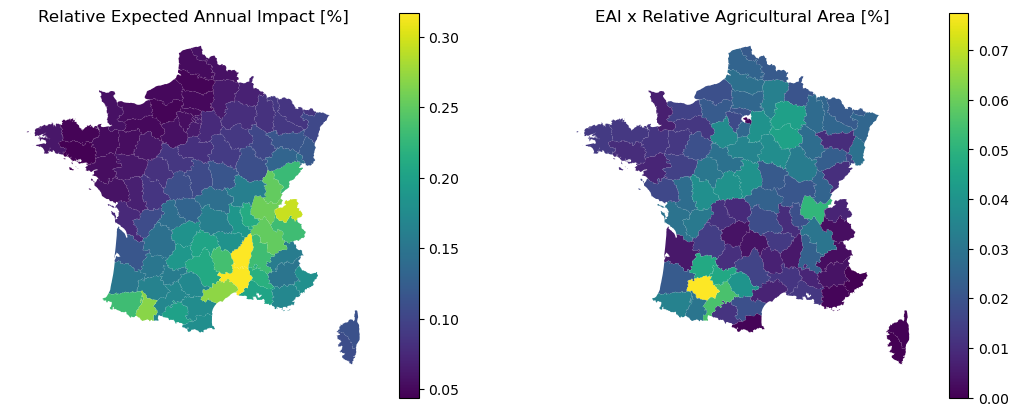

In [24]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2,
                        figsize=(13, 5))

axs[0].set_title("Relative Expected Annual Impact [%]")
impact_poly_gdf.plot(
    column="eai",
    ax=axs[0],
    cmap="viridis",
    legend=True
)

axs[1].set_title("EAI x Relative Agricultural Area [%]")
impact_poly_gdf.plot(
    column="rel_damaged_area",
    ax=axs[1],
    cmap="viridis",
    legend=True,
)

for ax in axs:
    ax.set_axis_off()

plt.savefig(FIGURE_FOLDER + "impact" + ".png",
            dpi=300, transparent=True)
plt.show()

## Plotting Scenarios Overview

In [25]:
insurance_scaling_factors = []
insured_area = []
who_pays = {"F": [], "I": [], "G": []}

for label, scenario in scenarios_dict.items():
    insurance_scaling_factors.append(label)
    insured_area.append(scenario["insured_area"])
    
    for k in who_pays:
        who_pays[k].append(scenario["who_pays_what"][k])
        
        
total_area = scenarios_dict[0]["scenario_poly"]["area"].sum()

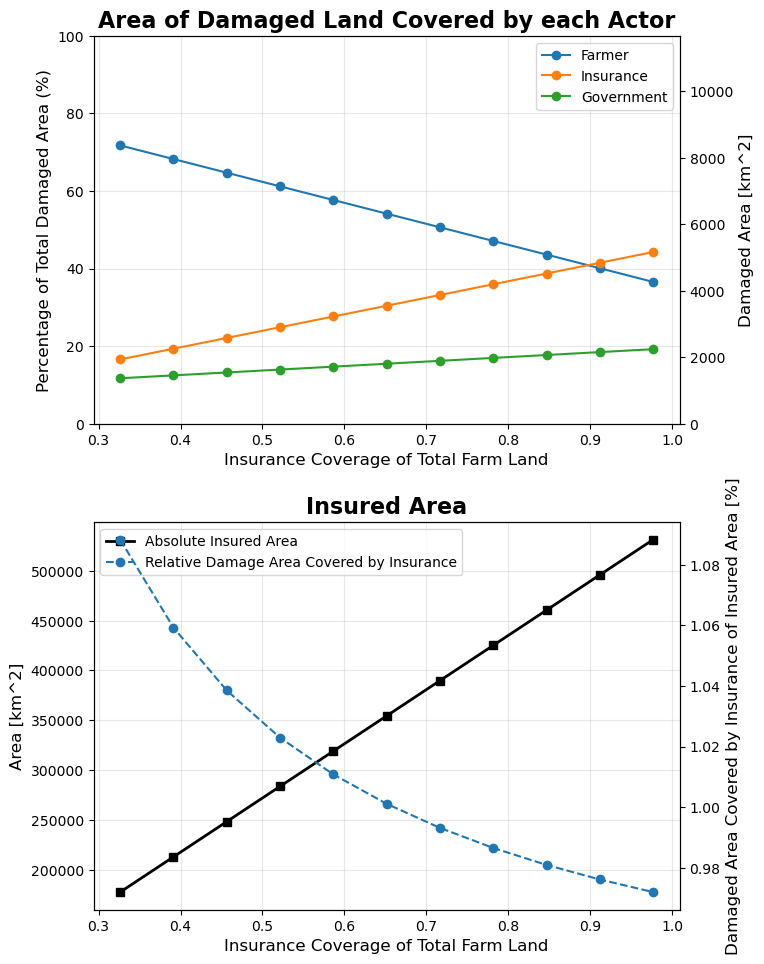

In [65]:
import matplotlib.pyplot as plt
import numpy as np

label_size = 12
label_weight = None

label_dict = {
    "F": "Farmer",
    "I": "Insurance",
    "G": "Government"
}

# Total damaged area (assuming first index holds totals)
area_total = exposure_poly_gdf["area"].sum()
damaged_area_total = who_pays["F"][0] + who_pays["G"][0] + who_pays["I"][0]
relative_insured_area = insured_area / area_total

fig, axs = plt.subplots(2, 1, figsize=(8, 10),
                        sharex=False)

# --- LEFT PLOT: Who pays What? ---
ax = axs[0]
ax.set_title("Area of Damaged Land Covered by each Actor",
             fontsize=16, fontweight="bold")

## Left: Relative Values
ax.set_ylim(0, 100)  # optional but often useful
ax.set_ylabel("Percentage of Total Damaged Area (%)", fontsize=label_size, fontweight=label_weight)
ax.set_xlabel("Insurance Coverage of Total Farm Land", fontsize=label_size, fontweight=label_weight)

## Right: Absolute Values
ax2 = ax.twinx()
ax2.set_ylabel("Damaged Area [km^2]", fontsize=label_size, fontweight=label_weight)

for label, values in who_pays.items():
    ax2.plot(
        relative_insured_area,
        values,
        marker="o",
        label=label_dict[label]
    )

ax2.legend()
ax2.set_ylim(0, damaged_area_total)


# --- RIGHT PLOT: Insurance Ratio
ax = axs[1]

# Left: Total Insured Area
ax.set_title("Insured Area", fontsize=16, fontweight="bold")
ax.plot(
    relative_insured_area,
    insured_area,
    color="black",
    linewidth=2,
    marker="s",
    label="Absolute Insured Area"
)

ax.set_ylabel("Area [km^2]", fontsize=label_size, fontweight=label_weight)
ax.set_xlabel("Insurance Coverage of Total Farm Land", fontsize=label_size, fontweight=label_weight)

# right: Ratio
relative_payed_area = (np.array(who_pays["I"]) / np.array(insured_area)) * 100

ax_right = ax.twinx()
ax_right.plot(
    relative_insured_area,
    relative_payed_area,
    color="tab:blue",
    linestyle="--",
    marker="o",
    label="Relative Damage Area Covered by Insurance"
)

ax_right.set_ylabel("Damaged Area Covered by Insurance of Insured Area [%]", fontsize=label_size, fontweight=label_weight)

# ---- combined legend ----
lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="best")


for ax in axs:
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout(pad=2.0)

plt.savefig(FIGURE_FOLDER + "scenario-overview" + ".png",
            dpi=300, transparent=True)
plt.show()

## Plotting Example Scenarios

In [28]:
from src.scenario_helpers import plot_scenario, plot_difference

scenarios_dict.keys()

max_rel_difference = (scenarios_dict[1.0]["scenario_poly"][["F_relative", "I_relative", "G_relative"]]
                      - scenarios_dict[0]["scenario_poly"][["F_relative", "I_relative", "G_relative"]]).max().max()

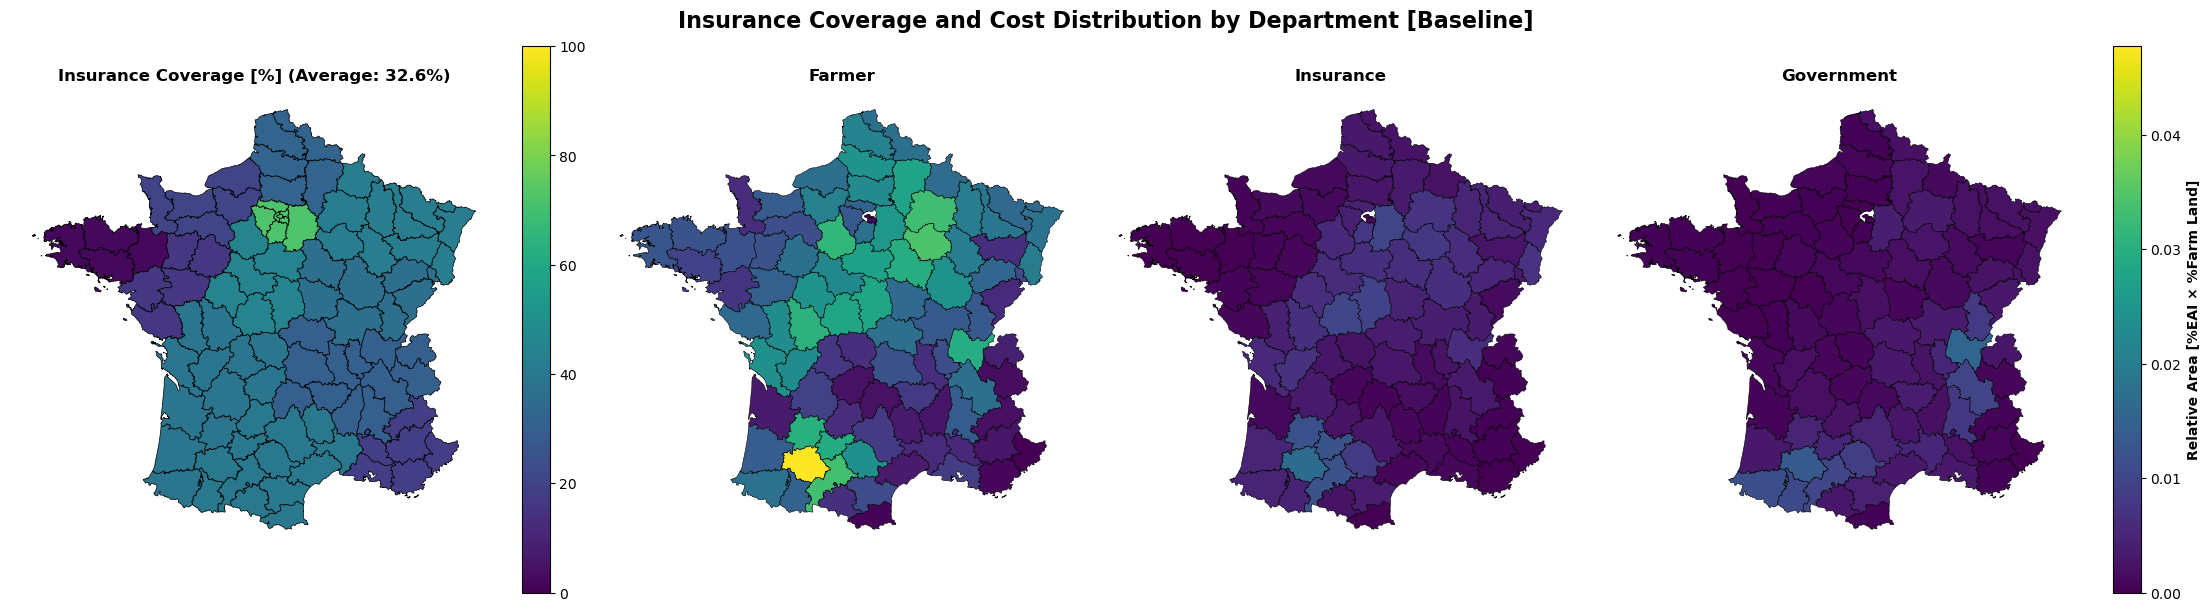

In [63]:
f, axs = plot_scenario(scenarios_dict[0], title_addition="[Baseline]")

plt.savefig(FIGURE_FOLDER + "baseline" + ".png",
            dpi=300, transparent=True)
plt.show()

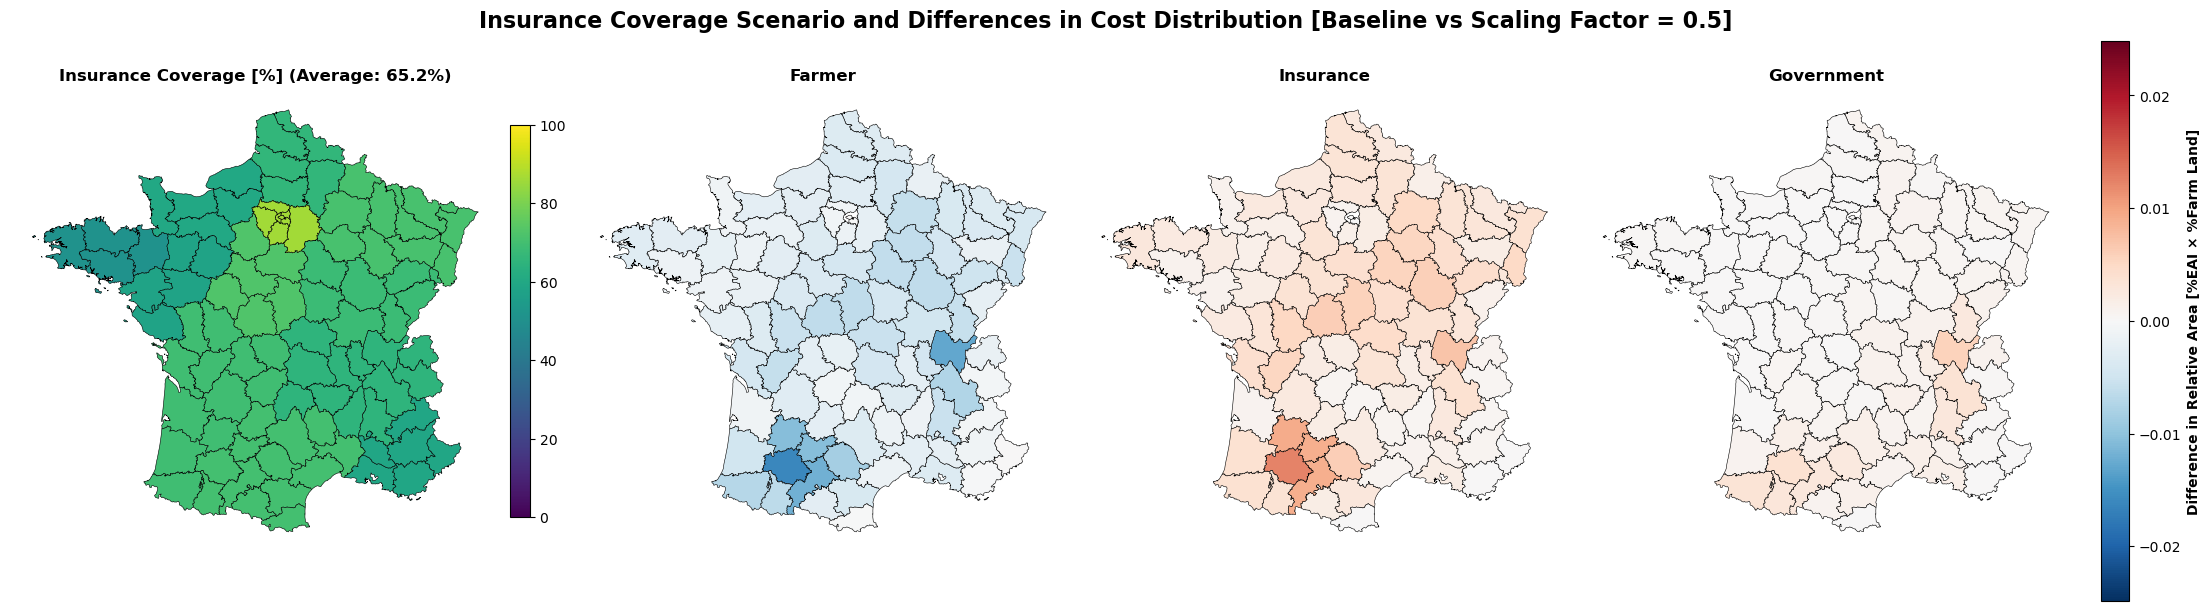

In [62]:
scenario_scaling_factor = 0.5

f, axs = plot_difference(scenarios_dict[0], scenarios_dict[scenario_scaling_factor],
                         rel_max=max_rel_difference,
                         title_addition=f"[Baseline vs Scaling Factor = {scenario_scaling_factor}]")

plt.savefig(FIGURE_FOLDER + "scenario-" + str(scenario_scaling_factor) + ".png",
            dpi=300, transparent=True)
plt.show()

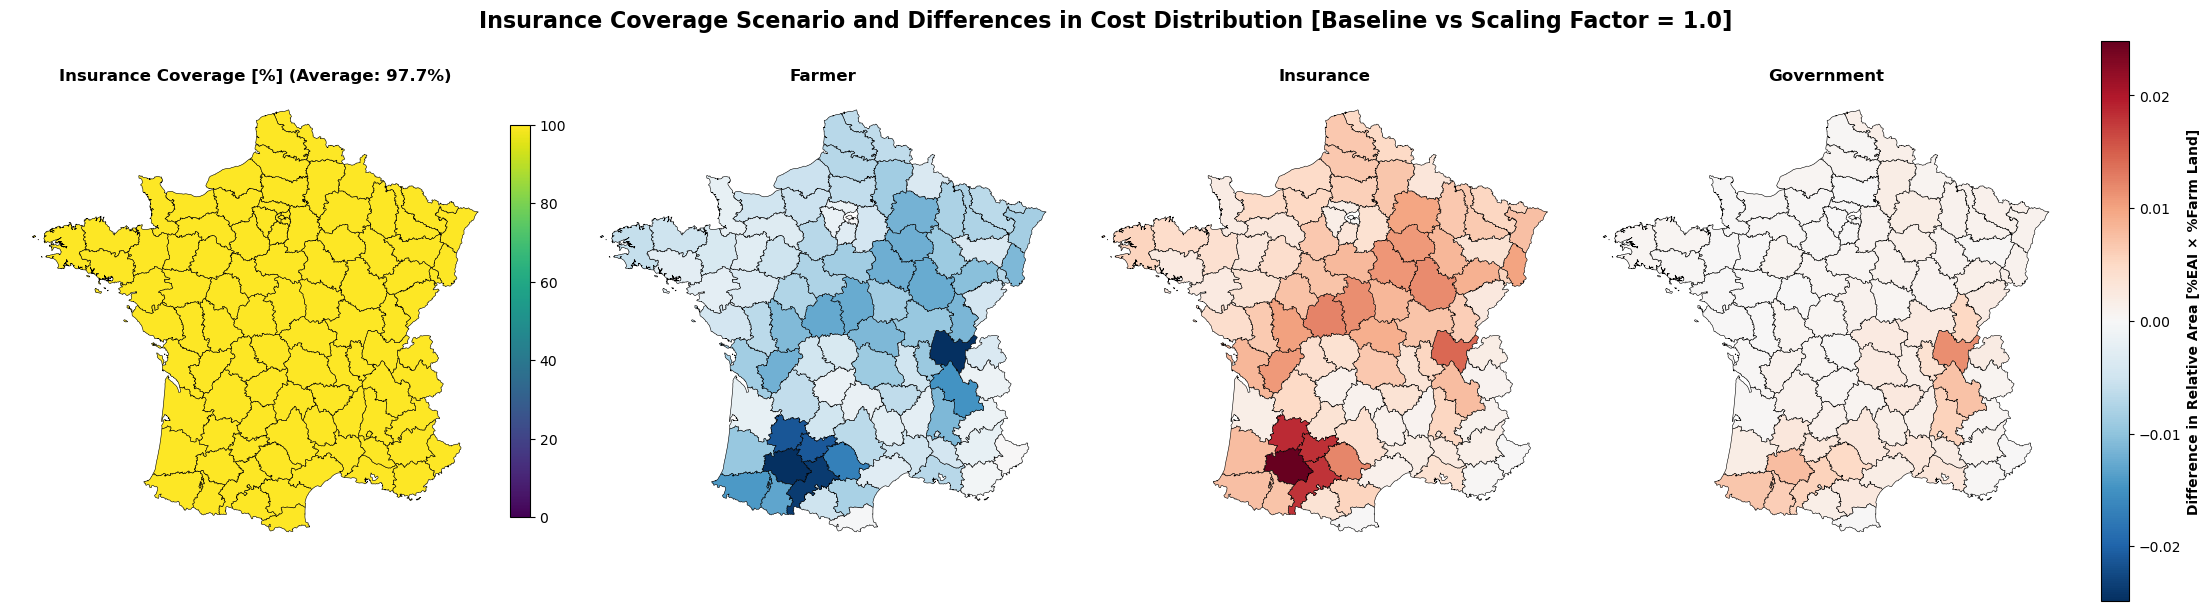

In [61]:
scenario_scaling_factor = 1.0

f, axs = plot_difference(scenarios_dict[0], scenarios_dict[scenario_scaling_factor],
                         rel_max=max_rel_difference,
                         title_addition=f"[Baseline vs Scaling Factor = {scenario_scaling_factor}]")

plt.savefig(FIGURE_FOLDER + "scenario-" + str(scenario_scaling_factor) + ".png",
            dpi=300, transparent=True)
plt.show()